# **Credit default prediction**

In [1]:
# Reproductability

SEED = 2026
import random
import numpy as np

def set_seed(seed: int = 2026):
  random.seed(seed)
  np.random.seed(seed)
set_seed(SEED)

In [2]:
# Dataset download

from sklearn.datasets import fetch_openml
# OpenML dataset: Default of Credit Card Clients (data_id=42477)
data = fetch_openml(data_id=42477, as_frame=True)
X = data.data
y = data.target  # may be string type depending on OpenML version
# If y is string, convert to int (example):
y = y.astype(int)


# Dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50,stratify=y_temp, random_state=42)


# Train class

Train_count=np.bincount(y_train.values)

print("Train class report:")
print(f"Non-Default(0) : {Train_count[0]}")
print(f"Default(1) : {Train_count[1]}")
print(f"Total : {len(y_train)} \n")


# Validation class

Val_count=np.bincount(y_val.values)

print("Validation class report:")
print(f"Non-Default(0) : {  Val_count[0]}")
print(f"Default(1) : {Val_count[1]}")
print(f"Total : {len(y_val)} \n")


# Test class

Test_count=np.bincount(y_test.values)

print("Test class report:")
print(f"Non-Default(0) : {  Test_count[0]}")
print(f"Default(1) : {Test_count[1]}")
print(f"Total : {len(y_test)} \n")


Train class report:
Non-Default(0) : 16355
Default(1) : 4645
Total : 21000 

Validation class report:
Non-Default(0) : 3505
Default(1) : 995
Total : 4500 

Test class report:
Non-Default(0) : 3504
Default(1) : 996
Total : 4500 



In [ ]:
print((X_train.isna().any())) # No missing values on the training set

x1     False
x2     False
x3     False
x4     False
x5     False
x6     False
x7     False
x8     False
x9     False
x10    False
x11    False
x12    False
x13    False
x14    False
x15    False
x16    False
x17    False
x18    False
x19    False
x20    False
x21    False
x22    False
x23    False
dtype: bool


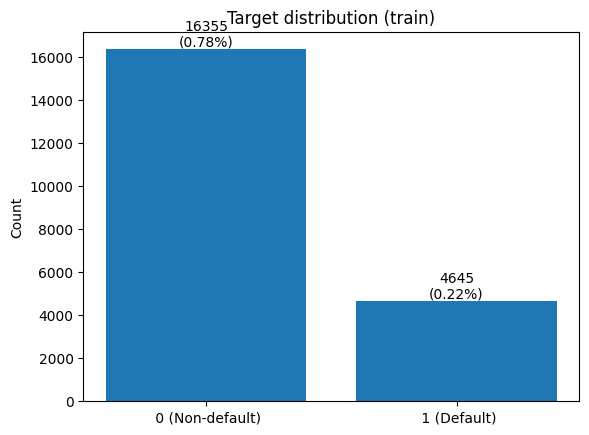

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

categories=[0,1]
bars = plt.bar(categories, Train_count )
plt.title("Target distribution (train)")
plt.xticks(categories, [' 0 (Non-default)', ' 1 (Default)'])
plt.ylabel("Count")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),f'{bar.get_height()}\n({round(bar.get_height()/len(y_train),2)}%)', ha='center', va='bottom')

plt.show()
plt.close()

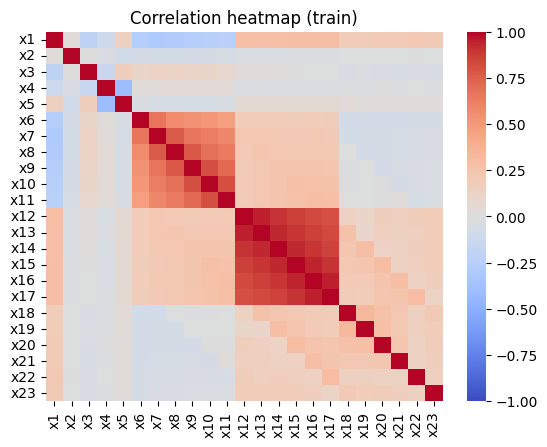

In [ ]:
import seaborn as sns

plt.figure()

corr_matrix = X_train.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlation heatmap (train)')
plt.show()

# Model Implementation (scikit-learn)

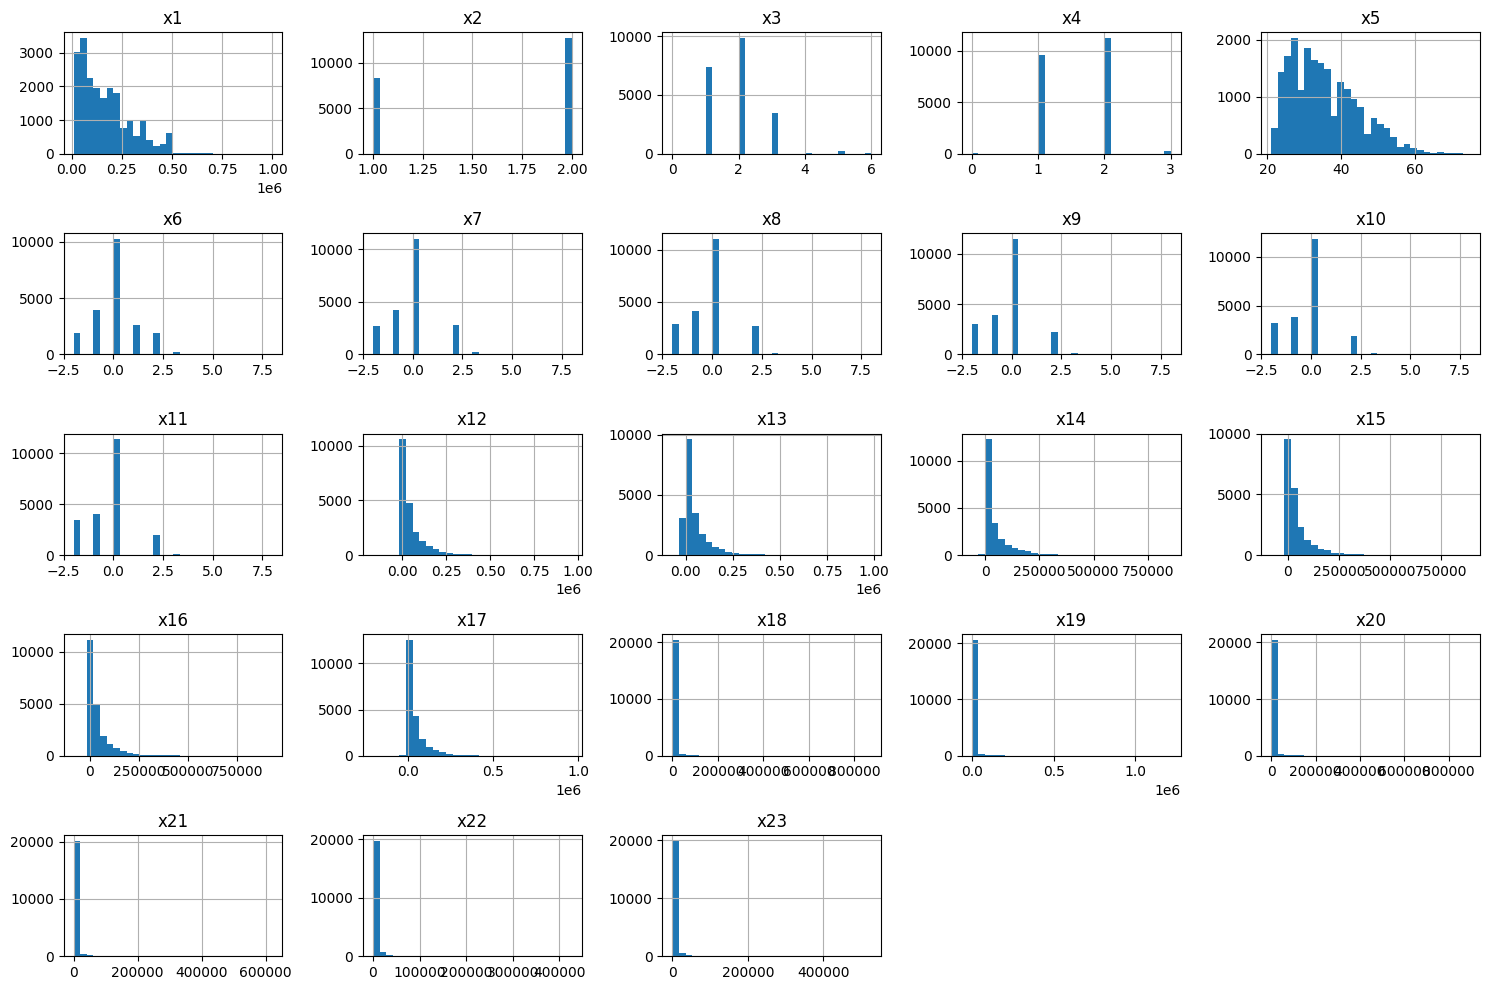

x1        77
x2         2
x3         7
x4         4
x5        55
x6        11
x7        11
x8        11
x9        11
x10       10
x11       10
x12    16574
x13    16364
x14    16093
x15    15820
x16    15376
x17    15090
x18     6369
x19     6347
x20     6042
x21     5598
x22     5496
x23     5511
dtype: int64


In [ ]:
# Pre-processing

X_train.hist(bins=30,figsize=(15, 10))
plt.tight_layout()
plt.show()
print(X_train.nunique())

In [18]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

rs=RobustScaler()
ohe=OneHotEncoder(drop='first')

ct=make_column_transformer(
    (ohe,['x2', 'x3', 'x4', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11']),
    (rs,['x1', 'x5', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23']))

X_train_scaled=ct.fit_transform(X_train)

X_val_scaled=ct.transform(X_val)

X_test_scaled=ct.transform(X_test)

In [20]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
import copy

table_hyperparam = []
best_models = dict()

models_and_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['lbfgs', 'liblinear'],
            'class_weight': [None, 'balanced']
        }
    },
    'Support Vector Machine': {
        'model': SVC(max_iter=3000, tol=0.1, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 5],
            'kernel': ['rbf'],
            'gamma': ['scale', 'auto'],
            'class_weight': [None, 'balanced']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [10, 50, 100],
            'max_depth': [None, 10],
            'min_samples_split': [2, 5]
        }
    },
    'Multi-Layer Perceptron': {
        'model': MLPClassifier(max_iter=1000, random_state=42),
        'params': {
            'hidden_layer_sizes': [(10,), (100,), (50, 50)],
            'alpha': [0.0001, 0.01],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

for model_name, config in models_and_params.items():
    print(f"Training {model_name}...") # this to monitor the "time" it takes especially for svm and mlp
    best_score = -1
    best_params = None

    param_grid = list(ParameterGrid(config['params']))

    for params in param_grid:

        model = clone(config['model']) # instead of modifying the model for each parameter combination, we gotta create one so that we can store the best for evaluation metrics
        model.set_params(**params)

        model.fit(X_train_scaled, y_train)

        y_val_pred = model.predict(X_val_scaled)
        current_score = f1_score(y_val, y_val_pred, average='macro')

        if current_score > best_score:
            best_score = current_score
            best_params = params
            best_model = copy.deepcopy(model)


    best_model.set_params(**best_params)
    best_model.fit(X_train_scaled, y_train)

    best_models[model_name] = best_model

    table_hyperparam.append({
        'Model': model_name,
        'Selected Hyperparameters': str(best_params),
        ' Score (F1)': round(best_score, 4)
    })

Training Logistic Regression...
Training Support Vector Machine (SVM)...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider

Training Random Forest...
Training Multi-Layer Perceptron...


In [21]:
print(table_hyperparam)

[{'Model': 'Logistic Regression', 'Selected Hyperparameters': "{'C': 1, 'class_weight': 'balanced', 'solver': 'liblinear'}", ' Score (F1)': 0.6876}, {'Model': 'Support Vector Machine (SVM)', 'Selected Hyperparameters': "{'C': 5, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}", ' Score (F1)': 0.4348}, {'Model': 'Random Forest', 'Selected Hyperparameters': "{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}", ' Score (F1)': 0.6769}, {'Model': 'Multi-Layer Perceptron', 'Selected Hyperparameters': "{'alpha': 0.01, 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001}", ' Score (F1)': 0.6795}]


#  Evaluation Metrics 

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

L_metrics = []
model_proba = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"): # we use the attributes of the models to have a numerical scores
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled) # if we use the probability for svm, it takes too long so we use its decision function


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    auroc = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)


    L_metrics.append({
        'Model': name,
        'Accuracy': round(acc, 3),
        'Precision (Class 1)': round(prec, 3),
        'Recall (Class 1)': round(rec, 3),
        'Macro-F1': round(f1_macro, 3),
        'AUROC': round(auroc, 3),
        'AUPRC': round(auprc, 3)
    })

    model_proba[name] = y_prob


table_metrics = pd.DataFrame(L_metrics)
print(table_metrics)

                          Model  Accuracy  Precision (Class 1)  \
0           Logistic Regression     0.775                0.493   
1  Support Vector Machine (SVM)     0.424                0.249   
2                 Random Forest     0.814                0.637   
3        Multi-Layer Perceptron     0.815                0.651   

   Recall (Class 1)  Macro-F1  AUROC  AUPRC  
0             0.573     0.691  0.760  0.536  
1             0.796     0.421  0.623  0.322  
2             0.365     0.676  0.760  0.530  
3             0.354     0.674  0.776  0.548  


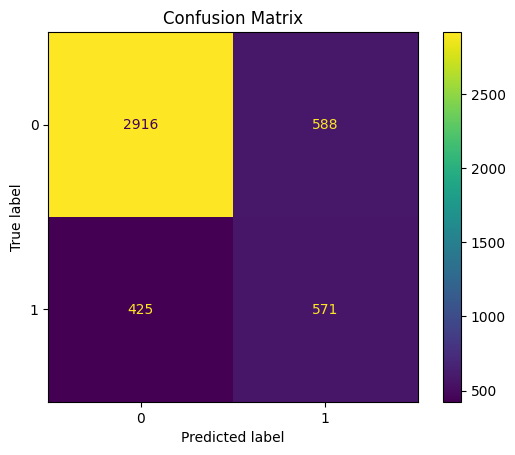

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = best_models['Logistic Regression'].predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

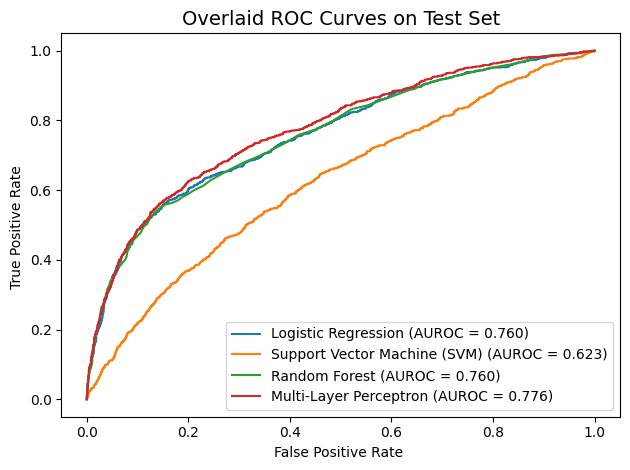

In [35]:
# Overlaid ROC

for name, y_prob in model_proba.items():
    fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
    auroc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr ,label=f'{name} (AUROC = {auroc:.3f})')

plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate ')
plt.title('Overlaid ROC Curves on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

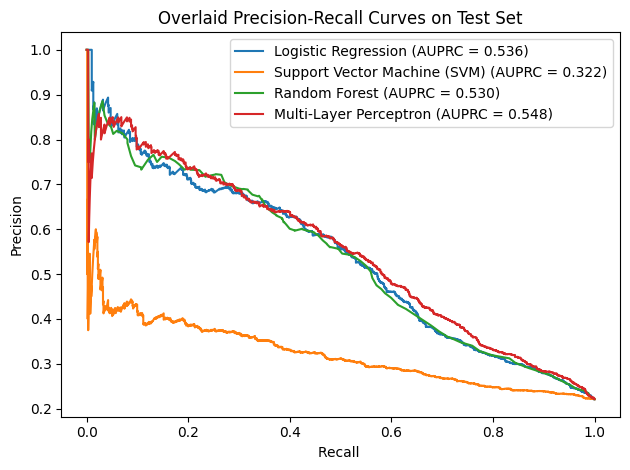

In [36]:
# Overlaid PR

for name, y_prob in model_proba.items():
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob, pos_label=1)
    auprc = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f'{name} (AUPRC = {auprc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Overlaid Precision-Recall Curves on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

#  Handling Imbalanced Data 

In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

best_models_smote = dict()
L_metrics_smote = []

for model_name, config in models_and_params.items():
    print(f"Tuning  (SMOTE)  : {model_name}...")

    best_score = -1
    best_params = None

    param_grid = list(ParameterGrid(config['params']))

    for params in param_grid:
        model = clone(config['model'])
        model.set_params(**params)

        model.fit(X_train_smote, y_train_smote)

        y_val_pred = model.predict(X_val_scaled)
        current_score = f1_score(y_val, y_val_pred, average='macro')

        if current_score > best_score:
            best_score = current_score
            best_params = params
            best_model = copy.deepcopy(model)

    best_model.set_params(**best_params)
    best_model.fit(X_train_smote, y_train_smote)
    best_models_smote[model_name] = best_model

    y_pred_test = best_model.predict(X_test_scaled)

    if hasattr(best_model, "predict_proba"):
        y_prob_test = best_model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob_test = best_model.decision_function(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, pos_label=1)
    rec = recall_score(y_test, y_pred_test, pos_label=1)
    f1_mac = f1_score(y_test, y_pred_test, average='macro')
    auroc = roc_auc_score(y_test, y_prob_test)
    auprc = average_precision_score(y_test, y_prob_test)

    L_metrics_smote.append({
        'Model (with SMOTE)': model_name,
        'Accuracy': round(acc, 3),
        'Precision (Class 1)': round(prec, 3),
        'Recall (Class 1)': round(rec, 3),
        'Macro-F1': round(f1_mac, 3),
        'AUROC': round(auroc, 3),
        'AUPRC': round(auprc, 3)
    })


table_smote_metrics = pd.DataFrame(L_metrics_smote)
print(table_smote_metrics)

Tuning  (SMOTE)  : Logistic Regression...
Tuning  (SMOTE)  : Support Vector Machine (SVM)...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider

Tuning  (SMOTE)  : Random Forest...
Tuning  (SMOTE)  : Multi-Layer Perceptron...
             Model (with SMOTE)  Accuracy  Precision (Class 1)  \
0           Logistic Regression     0.768                0.480   
1  Support Vector Machine (SVM)     0.374                0.242   
2                 Random Forest     0.800                0.556   
3        Multi-Layer Perceptron     0.739                0.435   

   Recall (Class 1)  Macro-F1  AUROC  AUPRC  
0             0.584     0.687  0.759  0.534  
1             0.857     0.374  0.645  0.360  
2             0.473     0.693  0.762  0.536  
3             0.598     0.663  0.747  0.498  
